<a href="https://colab.research.google.com/github/mprasads5/NASSCOM_VEDIC_Schedule1/blob/main/U9_%E2%80%94_EDA_%26_Statistical_Analysis_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()   # creates the two resource files locally
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Found the provided dataset files.


In [4]:
# Load the customer table (parse the date columns as real datetimes)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('ecommerce_customers.csv',
                 parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
print('Loaded', df.shape[0], 'customers x', df.shape[1], 'columns')
df.head()
# -----------------------------------------------------------
# 🔹 1A. STRUCTURE: what are we working with?
# -----------------------------------------------------------
df.info()   # column types + non-null counts

Loaded 2500 customers x 15 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       2500 non-null   object        
 1   signup_date       2500 non-null   datetime64[ns]
 2   first_order_date  2131 non-null   datetime64[ns]
 3   last_order_date   2131 non-null   datetime64[ns]
 4   age               2325 non-null   float64       
 5   gender            2400 non-null   object        
 6   city              2450 non-null   object        
 7   plan              2500 non-null   object        
 8   device            2500 non-null   object        
 9   payment_method    2500 non-null   object        
 10  num_orders        2500 non-null   int64         
 11  total_spend       2500 non-null   float64       
 12  support_tickets   2500 non-null   int64         
 13  email_opt_in      2500 non-null   int64    

In [5]:
# -----------------------------------------------------------
# 🔹 1B. QUALITY SNAPSHOT: missingness + the target balance
# -----------------------------------------------------------
print('Missing values (%):')
print((df.isna().mean() * 100).round(1).sort_values(ascending=False).head(6))
print('\nChurn rate (target):', round(df['is_churned'].mean(), 3))
print('Customers with zero orders:', int((df['num_orders'] == 0).sum()))

Missing values (%):
first_order_date    14.8
last_order_date     14.8
age                  7.0
gender               4.0
city                 2.0
signup_date          0.0
dtype: float64

Churn rate (target): 0.166
Customers with zero orders: 369


In [6]:
# 1. is customer_id unique?
print("Customer ID unique?:", df['customer_id'].is_unique)

# 2. numeric summary
print(df.describe())

# 3. Three issues I can see:
# - Missing values may exist in some columns (check with df.isna().sum()).
# - Some customers may have zero orders, which could indicate inactive users.
# - The target variable (is_churned) may be imbalanced, affecting model training.

Customer ID unique?: True
                      signup_date               first_order_date  \
count                        2500                           2131   
mean   2022-08-29 07:45:59.040000  2023-03-07 03:13:56.227123200   
min           2021-01-01 00:00:00            2021-01-24 00:00:00   
25%           2021-10-30 00:00:00            2022-07-06 12:00:00   
50%           2022-08-24 12:00:00            2023-04-22 00:00:00   
75%           2023-07-01 00:00:00            2023-12-05 00:00:00   
max           2024-04-30 00:00:00            2024-06-28 00:00:00   
std                           NaN                            NaN   

                     last_order_date          age   num_orders  total_spend  \
count                           2131  2325.000000  2500.000000  2500.000000   
mean   2024-01-01 16:56:59.239793664    37.888602     3.260800   112.272900   
min              2021-03-23 00:00:00    18.000000     0.000000     0.000000   
25%              2023-10-20 00:00:00    30.00

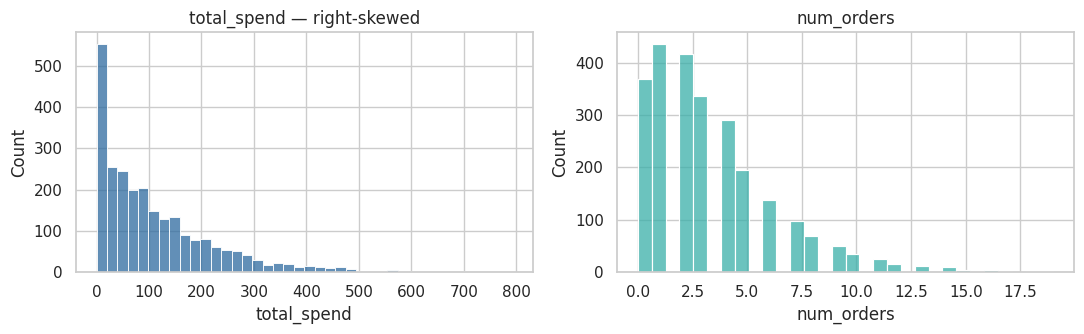

In [7]:
# -----------------------------------------------------------
# 🔹 2A. DISTRIBUTION OF SPEND  (note the long right tail)
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df['total_spend'], bins=40, ax=ax[0], color='#2D6A9F')
ax[0].set_title('total_spend — right-skewed')
sns.histplot(df['num_orders'], bins=30, ax=ax[1], color='#3AAFA9')
ax[1].set_title('num_orders')
plt.tight_layout(); plt.show()

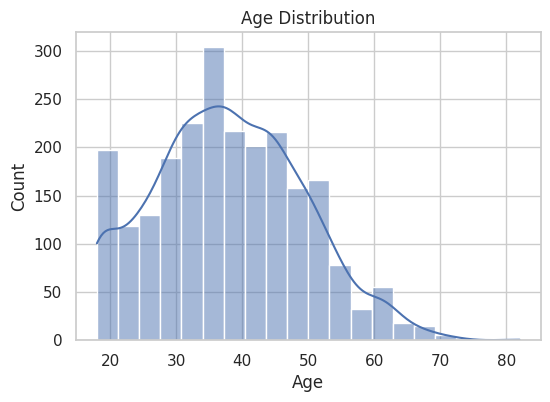

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'].dropna(), bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()
# The age distribution is roughly bell-shaped, with most customers
# concentrated in the middle-age range and relatively few very young
# or very old customers.

In [9]:
# -----------------------------------------------------------
# 🔹 3A. MEAN vs MEDIAN ON A SKEWED COLUMN
# -----------------------------------------------------------
# When data is right-skewed, the mean is pulled up by big spenders.
spend = df['total_spend']
print('mean  :', round(spend.mean(), 1))
print('median:', round(spend.median(), 1))
print('skew  :', round(spend.skew(), 2), ' (> 0 means right-skewed)')
print('\nThe mean > median gap is the skew talking.')

mean  : 112.3
median: 79.1
skew  : 1.73  (> 0 means right-skewed)

The mean > median gap is the skew talking.


In [10]:
# Compute skewness
print("Skew of num_orders  :", round(df['num_orders'].skew(), 3))
print("Skew of total_spend :", round(df['total_spend'].skew(), 3))

# Compare mean and median
print("\nnum_orders")
print("Mean  :", round(df['num_orders'].mean(), 2))
print("Median:", round(df['num_orders'].median(), 2))

print("\ntotal_spend")
print("Mean  :", round(df['total_spend'].mean(), 2))
print("Median:", round(df['total_spend'].median(), 2))

# Recommendation:
# If skewness is close to 0, the mean is a good measure of a typical customer.
# If skewness is strongly positive or negative, the median is preferred because
# it is less affected by extreme values (outliers).
# For customer datasets, total_spend is usually right-skewed, so the median
# often represents a typical customer better than the mean.

Skew of num_orders  : 1.353
Skew of total_spend : 1.732

num_orders
Mean  : 3.26
Median: 3.0

total_spend
Mean  : 112.27
Median: 79.12


In [11]:
# 1. skew of the two columns
print("Skew of num_orders  :", round(df['num_orders'].skew(), 3))
print("Skew of total_spend :", round(df['total_spend'].skew(), 3))

# Compare mean and median
print("\nnum_orders -> Mean:", round(df['num_orders'].mean(), 2),
      "| Median:", round(df['num_orders'].median(), 2))

print("total_spend -> Mean:", round(df['total_spend'].mean(), 2),
      "| Median:", round(df['total_spend'].median(), 2))

# 2 & 3. Which average for each, and why:
# - If num_orders has low skewness (close to 0), the mean is a good measure
#   because the distribution is fairly symmetric.
# - If total_spend is highly right-skewed, the median is better because a few
#   high-spending customers can pull the mean upward.
# - In general, use the mean for approximately symmetric data and the median
#   for strongly skewed data or data containing outliers.

Skew of num_orders  : 1.353
Skew of total_spend : 1.732

num_orders -> Mean: 3.26 | Median: 3.0
total_spend -> Mean: 112.27 | Median: 79.12


Plan mix:
plan
Basic       0.494
Standard    0.352
Premium     0.154
Name: proportion, dtype: float64

Top cities:
city
Mumbai       416
Delhi        405
Bengaluru    390
Hyderabad    320
Chennai      253
Name: count, dtype: int64


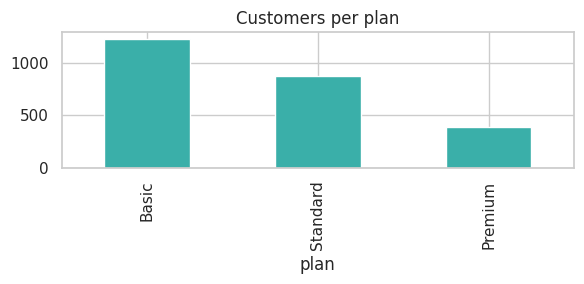

In [12]:
# -----------------------------------------------------------
# 🔹 4A. CATEGORY FREQUENCIES
# -----------------------------------------------------------
print('Plan mix:')
print(df['plan'].value_counts(normalize=True).round(3))
print('\nTop cities:')
print(df['city'].value_counts().head(5))

fig, ax = plt.subplots(figsize=(6, 3))
df['plan'].value_counts().plot(kind='bar', ax=ax, color='#3AAFA9')
ax.set_title('Customers per plan'); plt.tight_layout(); plt.show()

Churn vs Retained Proportions:
is_churned
0    0.834
1    0.166
Name: proportion, dtype: float64

Retained customers: 2085
Churned customers : 415
Imbalance Ratio (Retained / Churned): 5.02


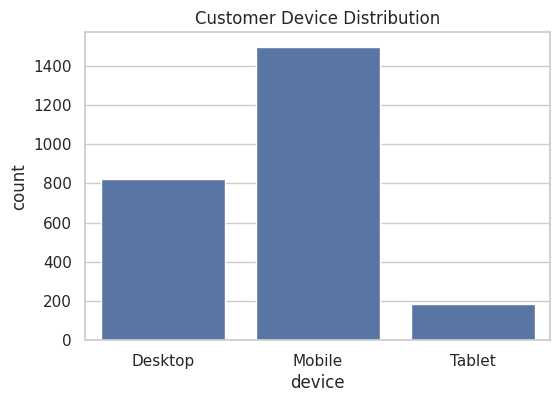

In [13]:
# 1. churn vs retained proportions
print("Churn vs Retained Proportions:")
print(df['is_churned'].value_counts(normalize=True))

# 2. imbalance ratio (retained / churned)
retained = (df['is_churned'] == 0).sum()
churned = (df['is_churned'] == 1).sum()

print("\nRetained customers:", retained)
print("Churned customers :", churned)
print("Imbalance Ratio (Retained / Churned):",
      round(retained / churned, 2))

# 3. bar chart of device
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='device')
plt.title('Customer Device Distribution')
plt.show()

# Comment:
# The device category with the highest bar is the dominant device type.
# If 'Mobile' has the tallest bar, most customers access the platform using mobile devices.

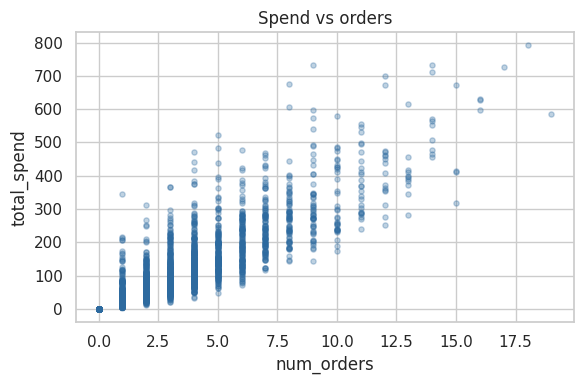

correlation: 0.864


In [14]:
# -----------------------------------------------------------
# 🔹 5A. DO SPEND AND ORDER COUNT MOVE TOGETHER?
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['num_orders'], df['total_spend'], alpha=0.3, color='#2D6A9F', s=14)
ax.set_xlabel('num_orders'); ax.set_ylabel('total_spend')
ax.set_title('Spend vs orders'); plt.tight_layout(); plt.show()

print('correlation:', round(df['num_orders'].corr(df['total_spend']), 3))

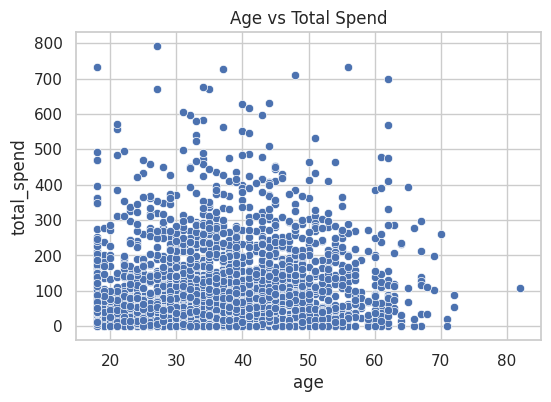

Correlation between age and total_spend: 0.007


In [15]:
# 1. scatter age vs total_spend
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='age', y='total_spend')
plt.title('Age vs Total Spend')
plt.show()

# 2. correlation
corr = df['age'].corr(df['total_spend'])
print("Correlation between age and total_spend:", round(corr, 3))

# 3. Interpretation:
# - If correlation is close to +1, older customers tend to spend more.
# - If correlation is close to -1, older customers tend to spend less.
# - If correlation is close to 0, there is little or no linear relationship
#   between age and total_spend.

            num_orders  total_spend  support_tickets
is_churned                                          
0                  3.6        125.5              0.6
1                  1.4         45.9              0.7


/tmp/ipykernel_456/3518072038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,


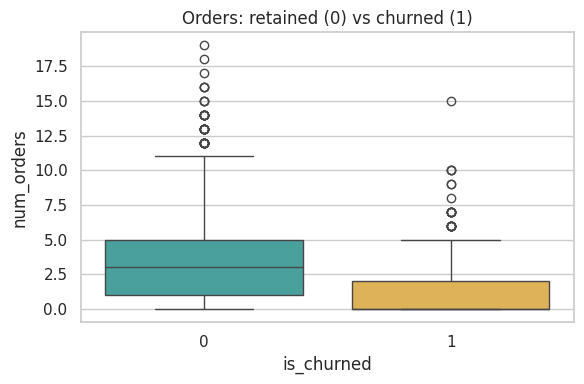

In [16]:
# -----------------------------------------------------------
# 🔹 6A. HOW DO CHURNERS DIFFER?  (group means)
# -----------------------------------------------------------
cols = ['num_orders', 'total_spend', 'support_tickets']
print(df.groupby('is_churned')[cols].mean().round(1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,
            palette=['#3AAFA9', '#F4B942'])
ax.set_title('Orders: retained (0) vs churned (1)')
plt.tight_layout(); plt.show()

is_churned
0    0.58801
1    0.73253
Name: support_tickets, dtype: float64


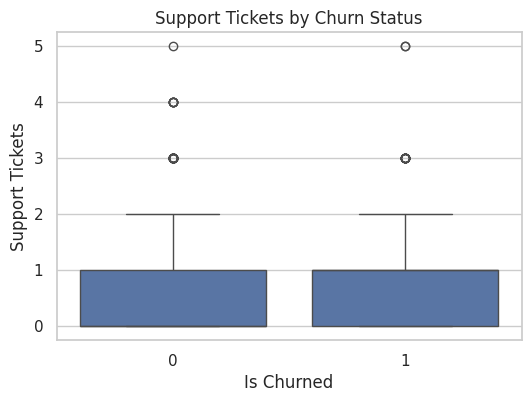

In [17]:
# 1. mean support_tickets by churn
print(df.groupby('is_churned')['support_tickets'].mean())

# 2. box plot of support_tickets by is_churned
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='is_churned', y='support_tickets')
plt.title('Support Tickets by Churn Status')
plt.xlabel('Is Churned')
plt.ylabel('Support Tickets')
plt.show()

# 3. Is it a warning sign?
# If churned customers have a noticeably higher average number of support tickets
# and the boxplot shows higher values for is_churned = 1, then frequent support
# issues may be a warning sign of customer dissatisfaction and potential churn.

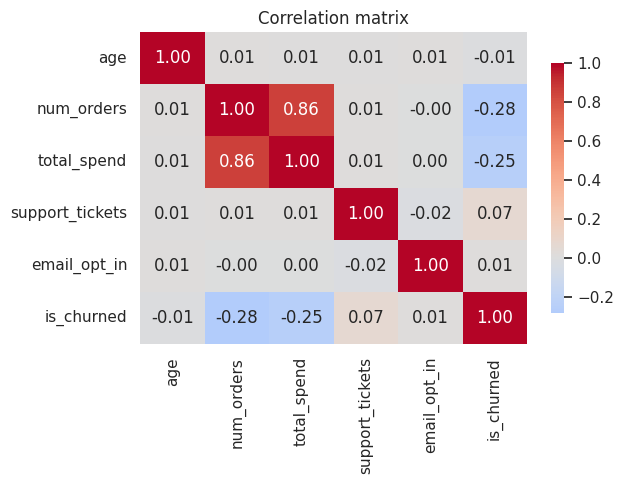

Correlation with churn (sorted):
num_orders        -0.282144
total_spend       -0.252546
age               -0.010746
email_opt_in       0.011145
support_tickets    0.068880
Name: is_churned, dtype: float64


In [18]:
# -----------------------------------------------------------
# 🔹 7A. WHAT CORRELATES WITH CHURN?
# -----------------------------------------------------------
num = ['age', 'num_orders', 'total_spend', 'support_tickets',
       'email_opt_in', 'is_churned']
corr = df[num].corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Correlation matrix'); plt.tight_layout(); plt.show()

print('Correlation with churn (sorted):')
print(corr['is_churned'].drop('is_churned').sort_values())

In [19]:
# 1. top-2 absolute correlations with churn

corr = df.corr(numeric_only=True)

top2 = (corr['is_churned']
        .drop('is_churned')
        .abs()
        .sort_values(ascending=False)
        .head(2))

print("Top 2 churn drivers (absolute correlation):")
print(top2)

# Optional: show actual correlations (with sign)
print("\nActual correlations:")
print(corr['is_churned'][top2.index])

# 2. Direction of each driver:
# - Positive correlation (+): As the feature increases, churn tends to increase.
# - Negative correlation (-): As the feature increases, churn tends to decrease.
# - The two features with the largest absolute correlations are the strongest
#   linear predictors of churn in this dataset.

Top 2 churn drivers (absolute correlation):
num_orders     0.282144
total_spend    0.252546
Name: is_churned, dtype: float64

Actual correlations:
num_orders    -0.282144
total_spend   -0.252546
Name: is_churned, dtype: float64


In [20]:
# -----------------------------------------------------------
# 🔹 8A. CHURN RATE BY SEGMENT
# -----------------------------------------------------------
print('Churn rate by plan:')
print(df.groupby('plan')['is_churned'].mean().round(3).sort_values(ascending=False))

print('\nChurn rate by device x plan:')
print(df.pivot_table(values='is_churned', index='plan',
                     columns='device', aggfunc='mean').round(3))

Churn rate by plan:
plan
Standard    0.174
Basic       0.163
Premium     0.158
Name: is_churned, dtype: float64

Churn rate by device x plan:
device    Desktop  Mobile  Tablet
plan                             
Basic       0.163   0.163   0.162
Premium     0.133   0.168   0.176
Standard    0.168   0.179   0.159


In [21]:
# 1. churn rate by payment_method
print("Churn Rate by Payment Method:")
print(df.groupby('payment_method')['is_churned'].mean().sort_values(ascending=False))

# 2. pivot: churn rate by plan x email_opt_in
pivot = pd.pivot_table(
    df,
    values='is_churned',
    index='plan',
    columns='email_opt_in',
    aggfunc='mean'
)

print("\nChurn Rate by Plan x Email Opt-In:")
print(pivot)

# 3. Worst-churning segment:
# Find the segment with the highest churn rate in the pivot table
worst = pivot.stack().idxmax()
worst_rate = pivot.stack().max()

print("\nWorst-churning segment:", worst)
print("Churn rate:", round(worst_rate, 3))

Churn Rate by Payment Method:
payment_method
Card          0.175097
UPI           0.168998
NetBanking    0.150943
Wallet        0.143266
Name: is_churned, dtype: float64

Churn Rate by Plan x Email Opt-In:
email_opt_in         0         1
plan                            
Basic         0.157407  0.165835
Premium       0.170370  0.151394
Standard      0.159864  0.180887

Worst-churning segment: ('Standard', np.int64(1))
Churn rate: 0.181


In [22]:
# -----------------------------------------------------------
# 🔹 9A. OUTLIERS IN SPEND (IQR rule)
# -----------------------------------------------------------
q1, q3 = df['total_spend'].quantile([0.25, 0.75])
iqr = q3 - q1
high = q3 + 1.5 * iqr
outliers = df[df['total_spend'] > high]
print(f'IQR upper bound: {high:.0f}')
print('Whale customers above it:', len(outliers))
print(outliers[['customer_id', 'num_orders', 'total_spend']]
      .sort_values('total_spend', ascending=False).head())

IQR upper bound: 365
Whale customers above it: 110
     customer_id  num_orders  total_spend
812    CUST00813          18       791.37
1176   CUST01177          14       732.79
875    CUST00876           9       732.24
562    CUST00563          17       727.37
768    CUST00769          14       710.47


In [23]:
# 1. skew of total_spend
skew_spend = df['total_spend'].skew()
print("Skew of total_spend:", round(skew_spend, 3))

# 2. churn rate (rare-class share)
churn_rate = df['is_churned'].mean()
print("Churn rate:", round(churn_rate, 3))

# 3. column with the most missing values
missing_col = df.isna().sum().idxmax()
missing_count = df.isna().sum().max()

print("Column with most missing values:", missing_col)
print("Missing values:", missing_count)

# 4. One fix per flag:
# skew -> Apply log transformation or use robust statistics (median/IQR).
# imbalance -> Use class weighting, oversampling (SMOTE), or undersampling.
# missing -> Impute missing values (mean/median/mode) or drop rows/columns if appropriate.

Skew of total_spend: 1.732
Churn rate: 0.166
Column with most missing values: first_order_date
Missing values: 369
